In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import io

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

In [3]:
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
resp = urllib.request.urlopen (url)
zf = zipfile.ZipFile(io.BytesIO(resp.read()))
zf.extractall("bike_data")

In [4]:
df = pd.read_csv("bike_data/hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [7]:
df["dteday"].value_counts()

dteday
2012-12-31    24
2011-01-01    24
2012-12-30    24
2012-12-29    24
2012-12-28    24
              ..
2011-01-26    16
2011-01-18    12
2012-10-30    11
2011-01-27     8
2012-10-29     1
Name: count, Length: 731, dtype: int64

In [8]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [9]:
# ============================================================
# EDA - VALIDATE CATEGORICAL COLUMNS
# ============================================================

In [10]:
categorical_candidates = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'hr']

for col in categorical_candidates:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index())
    print()

--- season ---
season
1    4242
2    4409
3    4496
4    4232
Name: count, dtype: int64

--- yr ---
yr
0    8645
1    8734
Name: count, dtype: int64

--- mnth ---
mnth
1     1429
2     1341
3     1473
4     1437
5     1488
6     1440
7     1488
8     1475
9     1437
10    1451
11    1437
12    1483
Name: count, dtype: int64

--- holiday ---
holiday
0    16879
1      500
Name: count, dtype: int64

--- weekday ---
weekday
0    2502
1    2479
2    2453
3    2475
4    2471
5    2487
6    2512
Name: count, dtype: int64

--- workingday ---
workingday
0     5514
1    11865
Name: count, dtype: int64

--- weathersit ---
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

--- hr ---
hr
0     726
1     724
2     715
3     697
4     697
5     717
6     725
7     727
8     727
9     727
10    727
11    727
12    728
13    729
14    729
15    729
16    730
17    730
18    728
19    728
20    728
21    728
22    728
23    728
Name: count, dtype: int64



In [11]:
# ============================================================
# EDA - TARGET & CONTINUOUS DISTRIBUTIONS
# ============================================================

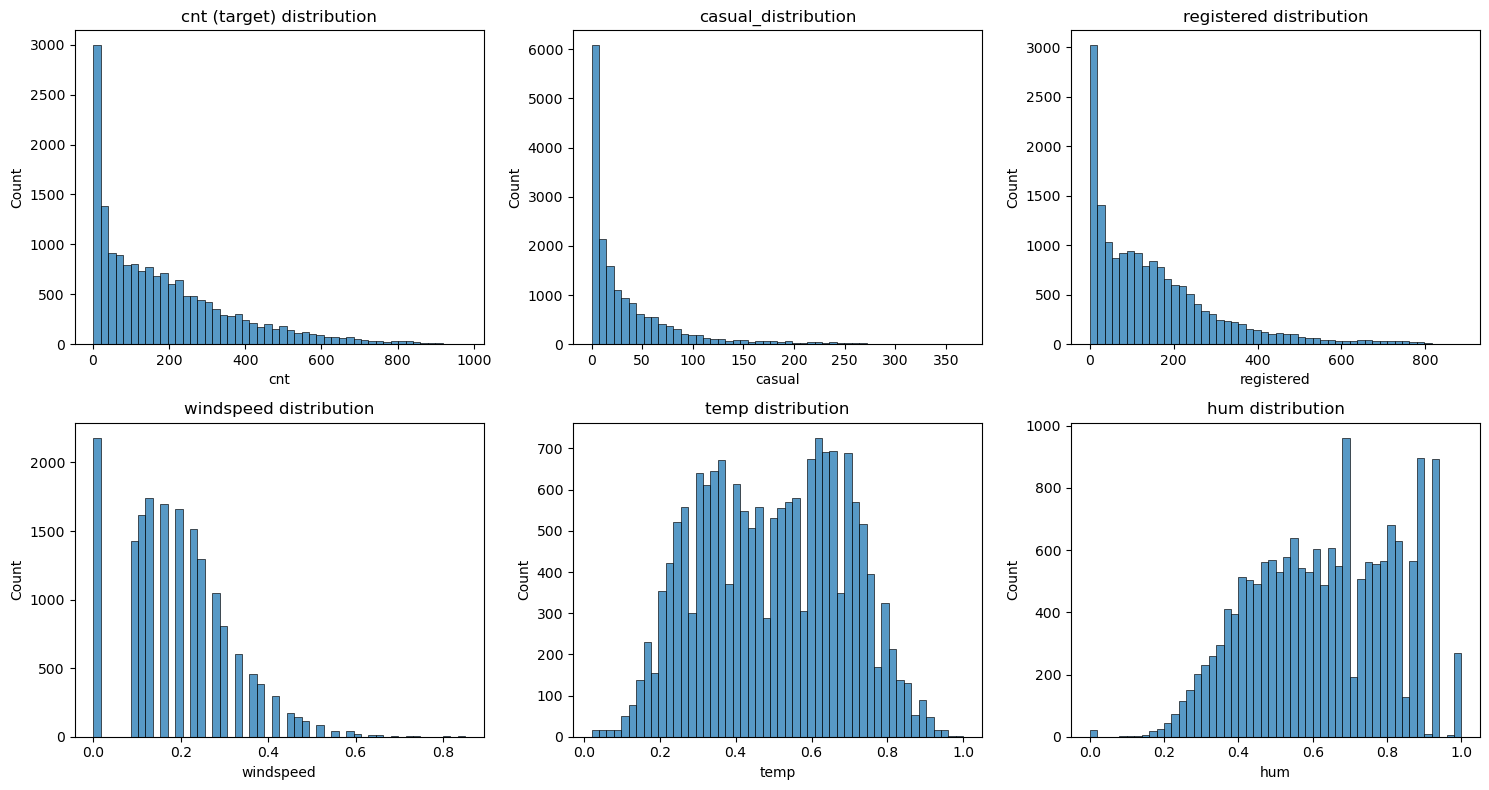

In [12]:
fig,axes = plt.subplots(2,3, figsize=(15,8))

sns.histplot(df["cnt"], bins=50, ax=axes[0,0])
axes[0,0].set_title("cnt (target) distribution")

sns.histplot(df["casual"],bins=50, ax=axes[0,1])
axes[0,1].set_title("casual_distribution")

sns.histplot(df["registered"], bins=50, ax=axes[0,2])
axes[0,2].set_title("registered distribution")

sns.histplot(df["windspeed"], bins=50, ax=axes[1,0])
axes[1,0].set_title("windspeed distribution")

sns.histplot(df["temp"], bins=50, ax=axes[1,1])
axes[1,1].set_title("temp distribution")

sns.histplot(df["hum"], bins= 50, ax=axes[1,2])
axes[1,2].set_title("hum distribution")

plt.tight_layout()
plt.show()


In [13]:

# Verify leakege claim: does casual + registered == cnt?
print((df["casual"] + df["registered"] == df["cnt"]).all())

True


In [14]:
# ============================================================
# EDA - TARGET BEHAVIOR BY HOUR AND SEASON
# ============================================================

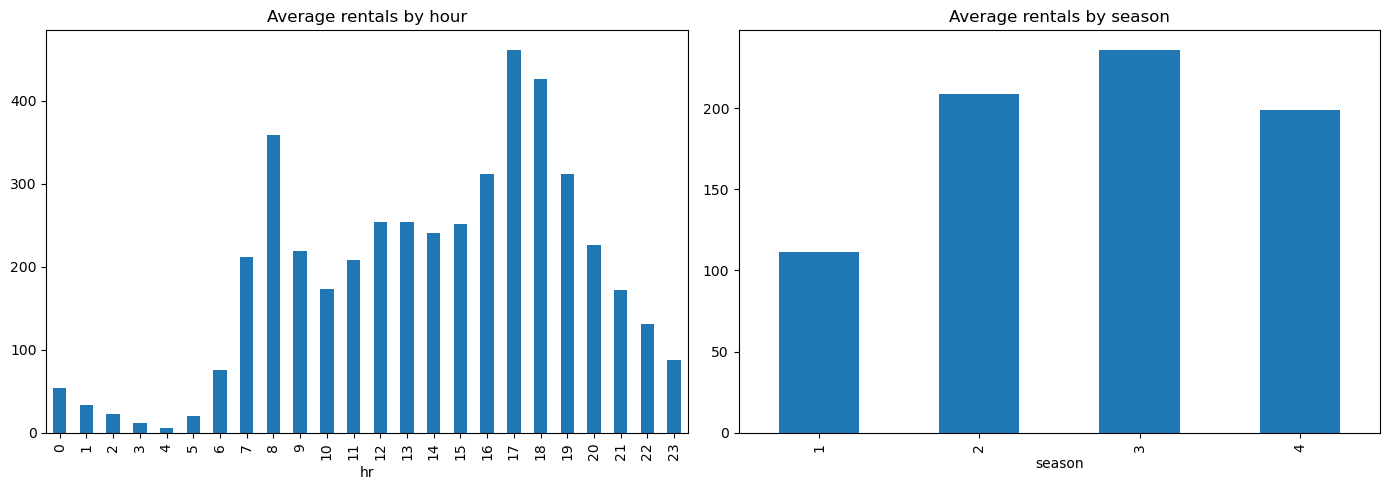

In [15]:
fig ,axes = plt.subplots(1,2, figsize=(14,5))

df.groupby("hr")["cnt"].mean().plot(kind="bar", ax = axes[0])
axes[0].set_title("Average rentals by hour")

df.groupby("season")["cnt"].mean().plot(kind="bar", ax = axes[1])
axes[1].set_title("Average rentals by season")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# EDA - QUANTIFY SKEWNESS
# ============================================================

In [17]:
for col in ["cnt","casual","registered","windspeed","temp","hum"]:
    print(f"{col}: skew = {df[col].skew():.3f}")

cnt: skew = 1.277
casual: skew = 2.499
registered: skew = 1.558
windspeed: skew = 0.575
temp: skew = -0.006
hum: skew = -0.111


In [18]:
# ============================================================
# EDA - CORRELATION HEATMAP
# ============================================================

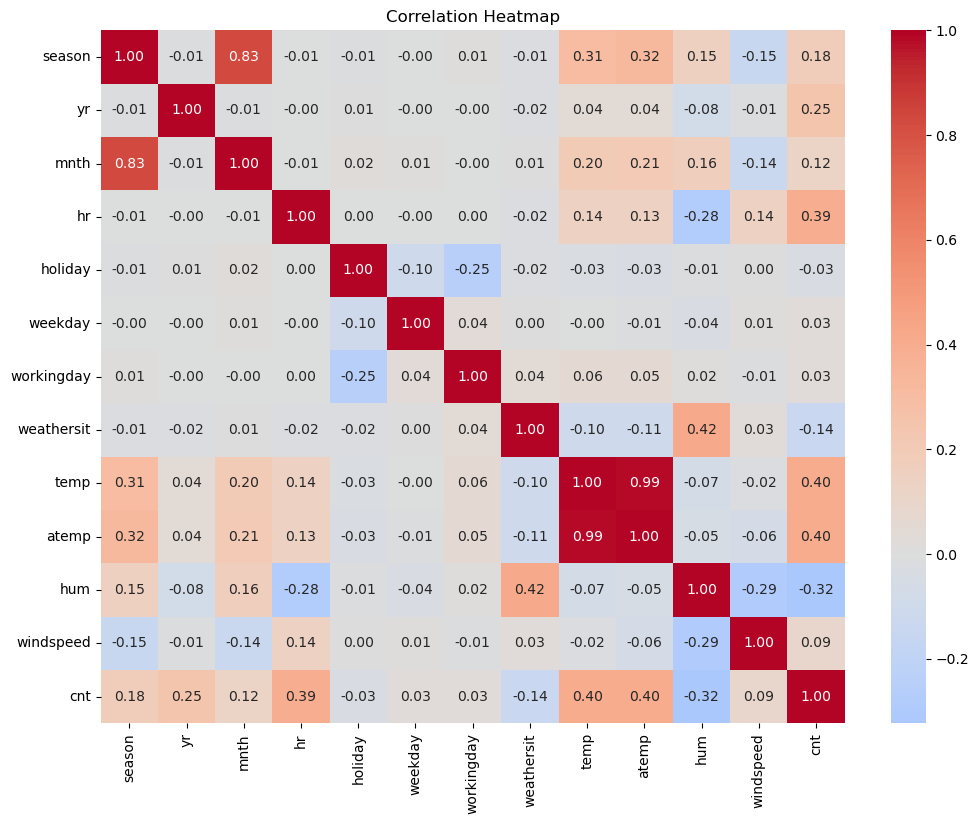

In [19]:
# Exclude leakage columns and identifiers from correlation check
corr_cols = ["season","yr","mnth","hr","holiday","weekday","workingday","weathersit","temp","atemp","hum","windspeed","cnt"]

plt.figure(figsize=(12,9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()



In [20]:
# ============================================================
# EDA - MULTICOLLINEARITY CHECK (VIF)
# ============================================================

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = ["season","yr","mnth","hr","holiday","weekday","workingday","weathersit","temp","atemp","hum","windspeed"]

X_vif=df[vif_features]
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]
vif_data.sort_values("VIF",ascending=False)

,feature,VIF
9,atemp,354.508062
8,temp,320.356672
0,season,21.133523
2,mnth,15.159659
10,hum,12.206201
7,weathersit,7.599369
3,hr,3.822101
11,windspeed,3.258951
6,workingday,3.236161
5,weekday,3.058983


In [27]:
# ============================================================
# PREPROCESSING - DROP LEAKAGE & REDUNDANT COLUMNS
# ============================================================

In [29]:
# casual & registered are leakage (their sum equals target cnt)
# instant is just a row index, no predictive value
# dteday is redundant (yr, mnth, hr, weekday already extracted from it)
# atemp dropped due to near-perfect correlation with temp (0.99, VIF 320-354)
# season dropped due to high correlation with mnth (0.83, VIF 15-21) - mnth kept for finer granularity

In [30]:
df= df.drop(columns=["instant","dteday","casual","registered","atemp","season"])

In [31]:
df.head()

,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,0,1,0,0,6,0,1,0.24,0.81,0.0,16
1,0,1,1,0,6,0,1,0.22,0.80,0.0,40
2,0,1,2,0,6,0,1,0.22,0.80,0.0,32
3,0,1,3,0,6,0,1,0.24,0.75,0.0,13
4,0,1,4,0,6,0,1,0.24,0.75,0.0,1


In [33]:
df.shape

(17379, 11)

In [34]:
# ============================================================
# PREPROCESSING - OUTLIER CHECK (IQR)
# ============================================================

In [37]:
# Check outliers on continuous columns only (categorical/ binary excluded)
continuos_col = ["temp","hum","windspeed","cnt"]

for col in continuos_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper )]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%), bounds=({lower:.3f},{upper:.3f})")

temp: 0 outliers (0.00%), bounds=(-0.140,1.140)
hum: 22 outliers (0.13%), bounds=(0.030,1.230)
windspeed: 342 outliers (1.97%), bounds=(-0.119,0.477)
cnt: 505 outliers (2.91%), bounds=(-321.500,642.500)


In [38]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X = df.drop(columns=["cnt"])
y = df["cnt"]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

print(X_train.shape, X_test.shape)

(13903, 10) (3476, 10)


In [41]:
# ============================================================
# ENCODING - NOMINAL CATEGORICAL COLUMNS
# ============================================================

In [42]:
# weathersit is nominal categorical (not truly ordinal in equal steps),
# one-hot encode it to avoid GBM assuming a false numeric order
# mnth, hr, weekday kept as numeric — GBM can split on them naturally 
# and they carry meaningful cyclical/ordinal signal (e.g. hr=17 is "close to" hr=18)

In [43]:
X_train = pd.get_dummies(X_train, columns=['weathersit'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['weathersit'], drop_first=True)

In [44]:
# Align columns in case a rare category (weathersit=4) doesn't appear in both splits
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [46]:
X_train.head()

,yr,mnth,hr,holiday,weekday,workingday,temp,hum,windspeed,weathersit_2,weathersit_3,weathersit_4
335,0,1,11,0,6,0,0.20,0.55,0.2239,False,False,False
7035,0,10,18,0,2,1,0.52,0.42,0.1045,False,False,False
8051,0,12,3,0,3,1,0.46,1.00,0.2239,False,True,False
2133,0,4,18,0,0,0,0.46,0.31,0.0000,True,False,False
8485,0,12,6,0,0,0,0.20,0.75,0.1045,False,False,False


In [47]:
X_train.shape, X_test.shape

((13903, 12), (3476, 12))

In [48]:
# ============================================================
# MODEL - GRADIENT BOOSTING (BASELINE)
# ============================================================

In [49]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [50]:
# No scaling needed - tree-based models are not distance-based

In [52]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train,y_train)

y_pred_train = gbr.predict(X_train)
y_pred_test = gbr.predict(X_test)

print("----TRAIN----")
print(f"MAE: {mean_absolute_error(y_train,y_pred_train):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train,y_pred_train)):.3f}")
print(f"R2: {r2_score(y_train,y_pred_train):.3f}")

print("----TEST----")
print(f"MAE: {mean_absolute_error(y_test,y_pred_test)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test,y_pred_test)):.3f}")
print(f"R2: {r2_score(y_test,y_pred_test):.3f}")



----TRAIN----
MAE: 48.444
RMSE: 71.460
R2: 0.846
----TEST----
MAE: 46.95212030326394
RMSE: 69.248
R2: 0.849


In [53]:
# ============================================================
# HYPERPARAMETER TUNING - GRIDSEARCHCV
# ============================================================

In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100,200,300],
    "learning_rate": [0.05,0.1,0.2],
    "max_depth":[2,3,4],
    "min_samples_leaf": [1,5,10]
}

gbr_base = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gbr_base,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train,y_train)

print("Best params:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 300}
Best CV RMSE: 46.05674725769558


In [55]:
# ============================================================
# EVALUATE BEST MODEL ON TEST SET
# ============================================================

best_gbr = grid_search.best_estimator_

y_pred_train = best_gbr.predict(X_train)
y_pred_test = best_gbr.predict(X_test)

print("---- Train ----")
print(f"MAE: {mean_absolute_error(y_train, y_pred_train):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f}")
print(f"R²: {r2_score(y_train, y_pred_train):.3f}")

print("---- Test ----")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")
print(f"R²: {r2_score(y_test, y_pred_test):.3f}")

---- Train ----
MAE: 25.565
RMSE: 39.603
R²: 0.953
---- Test ----
MAE: 27.934
RMSE: 44.006
R²: 0.939


In [56]:
# ============================================================
# CV RESULTS FROM GRIDSEARCH (ALREADY COMPUTED)
# ============================================================

In [57]:
print(f"Best CV RMSE (from GridSearch): {-grid_search.best_score_:.3f}")
# Get std of the best combination across the 5 folds
best_index = grid_search.best_index_
cv_std = grid_search.cv_results_['std_test_score'][best_index]
print(f"CV RMSE std: {cv_std:.3f}")

Best CV RMSE (from GridSearch): 46.057
CV RMSE std: 1.444


In [58]:
# ============================================================
# INSPECT CV RESULTS TABLE
# ============================================================

cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df[['param_learning_rate', 'param_max_depth', 'param_min_samples_leaf', 
               'param_n_estimators', 'mean_test_score', 'std_test_score']].sort_values(
               'mean_test_score', ascending=False).head(10)

,param_learning_rate,param_max_depth,param_min_samples_leaf,param_n_estimators,mean_test_score,std_test_score
80,0.2,4,10,300,-46.056747,1.444207
74,0.2,4,1,300,-46.399792,1.355360
77,0.2,4,5,300,-46.602532,1.579287
79,0.2,4,10,200,-47.515800,1.176092
73,0.2,4,1,200,-47.862002,1.346627
76,0.2,4,5,200,-48.059906,1.706982
50,0.1,4,5,300,-48.623918,0.642451
47,0.1,4,1,300,-48.972450,0.990385
53,0.1,4,10,300,-48.985378,1.056450
52,0.1,4,10,200,-50.888803,0.776463


In [59]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

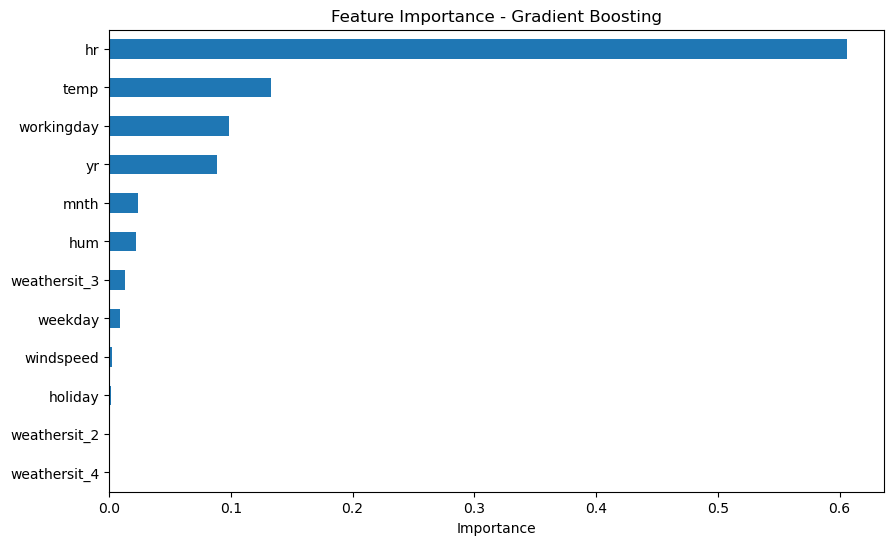

hr              0.606290
temp            0.133306
workingday      0.098803
yr              0.088929
mnth            0.023840
hum             0.021956
weathersit_3    0.012803
weekday         0.009334
windspeed       0.002714
holiday         0.001395
weathersit_2    0.000632
weathersit_4    0.000000
dtype: float64


In [61]:
importances = pd.Series(best_gbr.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance")
plt.show()

print(importances)

In [62]:
# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

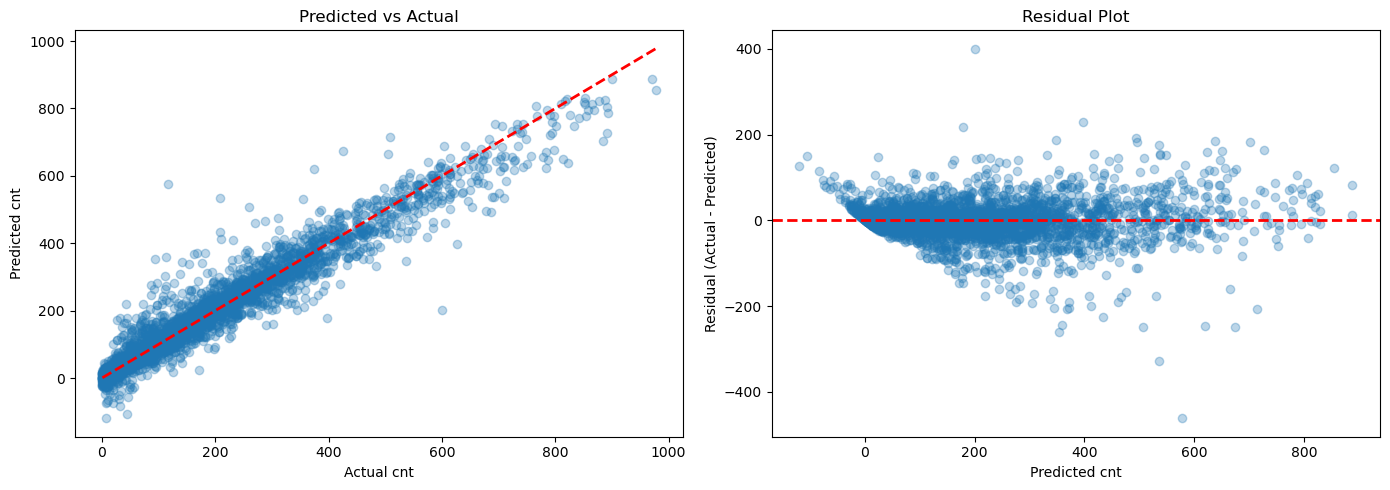

In [66]:
residuals = y_test - y_pred_test

fix, axes = plt.subplots(1,2, figsize=(14,5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],"r--", lw=2)
axes[0].set_xlabel("Actual cnt")
axes[0].set_ylabel("Predicted cnt")
axes[0].set_title("Predicted vs Actual")

#Residual plot
axes[1].scatter(y_pred_test,residuals, alpha=0.3)
axes[1].axhline(y=0, color="r",linestyle="--", lw=2)
axes[1].set_xlabel("Predicted cnt")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

In [67]:
# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

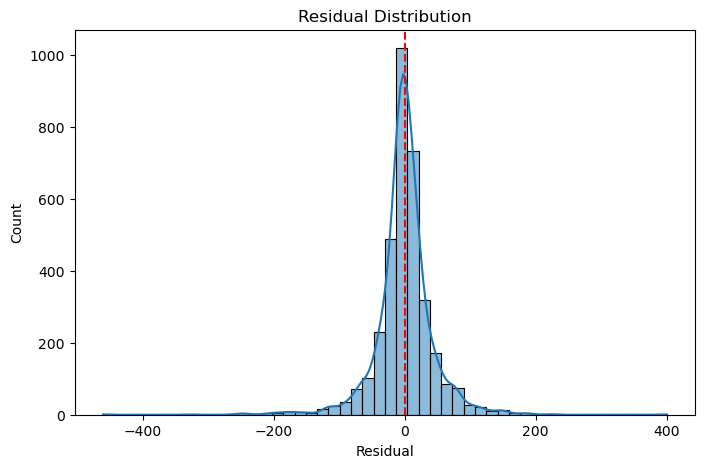

Residual mean: -0.578
Residual std: 44.009


In [69]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(x=0, color="r", linestyle="--")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

print(f"Residual mean: {residuals.mean():.3f}")
print(f"Residual std: {residuals.std():.3f}")